# Overhead điều phối Langflow với flow SCRFD

Notebook điều khiển CLI và đọc kết quả **offline mặc định**. Chỉ khi chủ động đặt `RUN_LIVE = True` mới khởi động worker/gửi request. Không có số liệu tốc độ giả lập trong notebook này; báo cáo lấy từ raw của `RUN_DIR`.

Mục tiêu: 1.000 request đo cho mỗi arm **00 / 01 / 10 / 11**, bốn block cân bằng. Bit đầu là compilation cache, bit sau là warm graph registry. Warmup tách khỏi 4.000 mẫu đo; HTTP connection reuse tắt.


## Ranh giới đo

`langflow_overhead_ms = server_total_ms - scrfd_processing_ms`

- `server_total_ms`: wall-clock monotonic trong worker từ điểm vào ASGI ngoài cùng của ứng dụng cho `/run` đến khi gửi xong response body.
- `scrfd_processing_ms`: độ dài **hợp** các khoảng output method của bốn node SCRFD, gồm preprocessing, inference, vẽ/lưu ảnh; phần chồng lấn chỉ trừ một lần.
- Chat Input/Output, chuẩn bị graph/component, validation, auth và toàn bộ middleware ứng dụng và serialize response vẫn thuộc overhead. Raw có thể chứa span của các node này nhưng chúng không được trừ.
- Upload, tải ảnh kết quả và mạng client nằm ngoài chỉ số chính. Đây không phải CPU time hoặc latency end-user.

Mỗi request vẫn chạy thật qua API production với `input_type=chat`, `output_type=chat`, `stream=false`; kiểm tra số mặt và hash pixels ảnh so với reference.

**Phạm vi implementation:** số liệu áp dụng cho đường warm đã sửa trong checkout này: file tweaks an toàn trên graph riêng từng request, xác minh auto-global không đổi binding, và phát lại sự kiện migration lỗi khi không có sửa kiểu node, giữ namespace người dùng. Sửa kiểu, metadata chưa biết hoặc tweaks chưa hỗ trợ vẫn cold. Đây không phải phép đo chỉ bật cờ upstream nguyên bản. Compilation cache lưu artifact biên dịch source; benchmark không thêm cache class instance, ONNX session hay kết quả inference.


In [1]:
import json
import shlex
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

from IPython.display import HTML, Image, display

# Chạy được khi notebook mở tại repository root hoặc thư mục benchmark_analyst.
_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((p for p in _candidates if (p / "benchmark_analyst" / "reporting.py").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Mở notebook từ repository langflow_CV hoặc đặt REPO_ROOT tuyệt đối.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RUNS = REPO_ROOT / "benchmark_analyst" / "runs"
RUN_DIR = RUNS / "main-v2"  # Đổi sang thư mục raw cần phân tích offline.
RUN_LIVE = False  # Mặc định an toàn: không chạy server, upload hoặc inference.

# Chỉ dùng nếu RUN_LIVE=True. Mỗi thư mục output phải chưa tồn tại.
LABEL = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
INPUT_CONFIG = RUNS / "inputs" / "config.json"
ENV_FILE = REPO_ROOT / ".env"
CREDENTIALS_FILE = RUNS / "inputs" / "credentials.env"
REFERENCE_DIR = RUNS / f"reference-{LABEL}"
SMOKE_DIR = RUNS / f"smoke-{LABEL}"
PORT = 7860
REQUESTS_PER_ARM = 1000
BLOCKS = 4
WARMUPS = 5
print("Chế độ:", "LIVE" if RUN_LIVE else "OFFLINE", "| Thư mục:", RUN_DIR)

Chế độ: OFFLINE | Thư mục: /Users/tranquangtrong/Desktop/langflow_CV/benchmark_analyst/runs/main-v2


## Thiết kế và dữ liệu đầu vào

| Block | Thứ tự arm |
| --- | --- |
| 1 | 00 → 01 → 11 → 10 |
| 2 | 01 → 10 → 00 → 11 |
| 3 | 10 → 11 → 01 → 00 |
| 4 | 11 → 00 → 10 → 01 |

Mỗi slot khởi động một worker độc lập, concurrency 1: **5 warmup + 250 request đo**. Tổng cộng 16 slot, 4.000 mẫu đo và 80 warmup. Flow/input/model phải giữ nguyên.

`INPUT_CONFIG` chứa `flow_id`, `input_node_id`, `output_node_id`, `scrfd_node_ids` (bốn ID), `image_path`, `model_path`, `flow_export_path`, `expected_faces`, `timeout_seconds`. Đường dẫn tương đối tính từ file config. `LANGFLOW_API_KEY` nằm trong credentials dotenv hoặc môi trường; không chép key vào notebook. Xem README để có mẫu config.


In [2]:
CLI = ["uv", "run", "--no-sync", "python", "-m", "benchmark_analyst.benchmark_langflow"]
AUTH_ARGS = ["--env-file", str(ENV_FILE), "--credentials-file", str(CREDENTIALS_FILE), "--port", str(PORT)]


def run_cli(arguments):
    command = CLI + [str(arg) for arg in arguments]
    # Chỉ hiển thị lệnh và đường dẫn, không đọc/hiển thị nội dung credentials.
    print(shlex.join(command))
    return subprocess.run(command, cwd=REPO_ROOT, check=True)

## Tùy chọn chạy thật: chuẩn bị reference

Cell này chỉ thực thi khi `RUN_LIVE=True`. CLI xác minh flow trong database khớp bản export rồi chạy một request thật, lưu ảnh reference và `config.json` đã có `reference_pixel_sha256`. Kiểm tra ảnh/số mặt dưới đây trước khi chạy smoke. Giữ source cố định từ trước smoke đến hết campaign; runner kiểm tra cả dirty/untracked source liên quan.


In [3]:
if RUN_LIVE:
    run_cli(["prepare", "--config", INPUT_CONFIG, "--output", REFERENCE_DIR, *AUTH_ARGS])
    display(Image(filename=str(REFERENCE_DIR / "reference.jpg")))
else:
    print("OFFLINE: bỏ qua chuẩn bị reference.")

OFFLINE: bỏ qua chuẩn bị reference.


## Tùy chọn chạy thật: smoke bốn arm

Smoke có 8 request/arm, hai request/slot, vẫn 5 warmup. Nó kiểm tra đường chạy, output và counter, không đủ để kết luận tốc độ. Chỉ tiếp tục campaign chính khi smoke VALID. Nếu sửa source/workload sau smoke, chạy smoke mới.


In [4]:
if RUN_LIVE:
    run_cli(
        [
            "run",
            "--config",
            REFERENCE_DIR / "config.json",
            "--output",
            SMOKE_DIR,
            "--requests-per-arm",
            8,
            "--blocks",
            BLOCKS,
            "--warmups",
            WARMUPS,
            *AUTH_ARGS,
        ]
    )
    smoke_analysis = json.loads((SMOKE_DIR / "analysis.json").read_text(encoding="utf-8"))
    if not smoke_analysis["valid"]:
        raise RuntimeError("Smoke INVALID: xem report.html và sửa nguyên nhân trước campaign chính.")
    print("Smoke VALID:", SMOKE_DIR / "report.html")
else:
    print("OFFLINE: bỏ qua smoke.")

OFFLINE: bỏ qua smoke.


## Tùy chọn chạy thật: 4.000 request đo

`--smoke` là bắt buộc cho campaign chính; runner xác nhận source và workload khớp smoke. Output phải là thư mục mới. Không chạy test/build hoặc tác vụ nặng cùng lúc. Lỗi được giữ lại, không retry bù; campaign dở dang không tự resume. Không sửa notebook/source giữa smoke và bước này.


In [5]:
if RUN_LIVE:
    run_cli(
        [
            "run",
            "--config",
            REFERENCE_DIR / "config.json",
            "--output",
            RUN_DIR,
            "--smoke",
            SMOKE_DIR,
            "--requests-per-arm",
            REQUESTS_PER_ARM,
            "--blocks",
            BLOCKS,
            "--warmups",
            WARMUPS,
            *AUTH_ARGS,
        ]
    )
else:
    print("OFFLINE: bỏ qua campaign; các cell tiếp theo chỉ phân tích RUN_DIR.")

OFFLINE: bỏ qua campaign; các cell tiếp theo chỉ phân tích RUN_DIR.


## Phân tích offline và kiểm chứng VALID / INVALID

Ba raw bắt buộc: `manifest.json`, `requests.jsonl`, `worker_evidence.jsonl`. `state.json` nếu có phải là COMPLETE. Hàm `analyze` không gọi API và không sửa raw; ghi lại các artifact `analysis.json`, `report.md`, `report.html`, `summary.csv`, `charts.png`.

Kiểm chứng số lượng chính xác mỗi slot, warmup, output/pixels, timing hữu hạn/không âm, hợp khoảng bốn node và phép trừ. PID/cờ phải nhất quán; warm ON có hit ở mọi request đo và zero cold; OFF có cold ở mọi request và zero hit. Compilation ON có measured hit; OFF zero hit và có bypass. Bật cờ không chứng minh cache hoạt động.


In [6]:
from benchmark_analyst.reporting import analyze

analysis = None
if RUN_DIR.is_dir():
    analysis = analyze(RUN_DIR)
    status = "VALID" if analysis["valid"] else "INVALID"
    scope = "CAMPAIGN 1.000 request/arm" if analysis["is_full_campaign"] else "SMOKE / cấu hình thử"
    print(status, "|", scope)
    for message in analysis["validation_errors"]:
        print("-", message)
else:
    print("Chưa có thư mục raw. Đặt RUN_DIR đến kết quả có sẵn rồi chạy lại các cell offline.")

VALID | CAMPAIGN 1.000 request/arm


## Mean, p50, p95, p99 và khác biệt giữa các block

Thống kê không gồm warmup. Percentile dùng nội suy tuyến tính type 7. Khi INVALID, số liệu chỉ phục vụ chẩn đoán; không lọc mẫu lỗi rồi coi phần còn lại là một campaign hợp lệ. So sánh mean và cả p95/p99 để thấy chi phí ở phần đuôi; xem mean từng block để nhận ra thay đổi theo thời gian/máy.


In [7]:
if analysis is not None:
    display(HTML((RUN_DIR / "report.html").read_text(encoding="utf-8")))

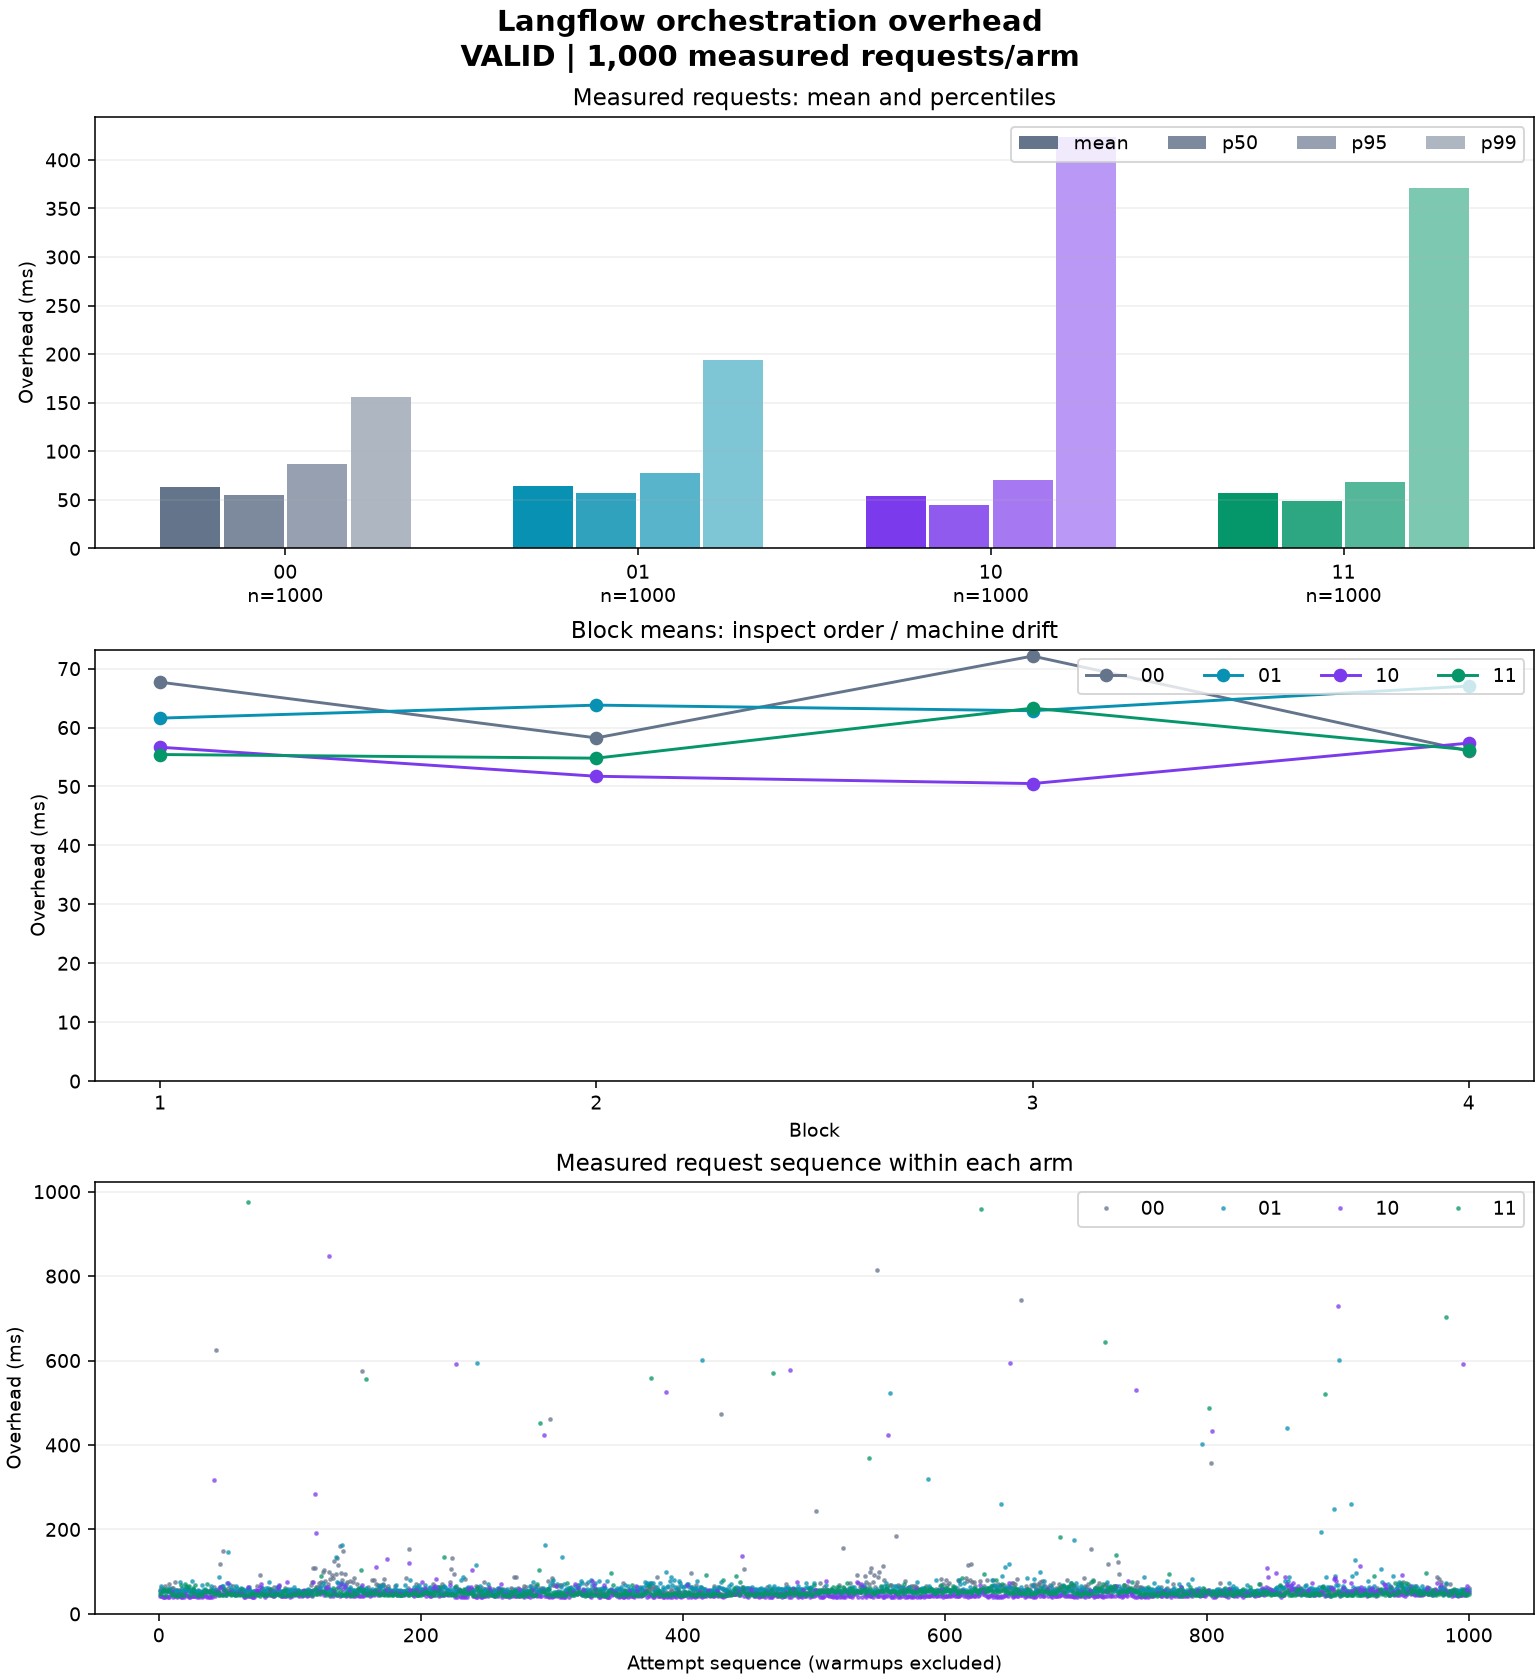

In [8]:
if analysis is not None:
    display(Image(filename=str(RUN_DIR / "charts.png")))

## Diễn giải hiệu ứng và giới hạn

Với μ là mean overhead, Δ âm nghĩa là overhead giảm:

- Bật riêng/kết hợp so với 00: μ10−μ00, μ01−μ00, μ11−μ00.
- Compilation khi warm OFF/ON: μ10−μ00, μ11−μ01.
- Warm khi compilation OFF/ON: μ01−μ00, μ11−μ10.
- Tương tác: μ11−μ10−μ01+μ00. Âm nghĩa là mức giảm kết hợp lớn hơn tổng hai mức giảm riêng theo thang ms.

`reduction_pct` dương nghĩa là overhead giảm, âm nghĩa là chậm hơn. Không giả định cache luôn có lợi. `contrasts=None` khi dữ liệu INVALID. Smoke dù VALID cũng chỉ xác minh đường chạy.

Chỉ có bốn block độc lập; 4.000 request không phải 4.000 lần lặp độc lập của điều kiện máy. Báo cáo không đưa CI/p-value. Không suy rộng từ overhead này thành latency end-user hoặc thành mọi workload/thiết bị.


In [9]:
if analysis is not None:
    if not analysis["valid"]:
        print("Không kết luận tăng tốc: dữ liệu INVALID.")
    elif not analysis["is_full_campaign"]:
        print("Smoke VALID: chỉ xác minh đường chạy; chưa có kết luận tốc độ campaign.")
    else:
        print(json.dumps(analysis["contrasts"], ensure_ascii=False, indent=2))
    print("Artifacts:")
    for filename in ("analysis.json", "report.md", "report.html", "summary.csv", "charts.png"):
        print(RUN_DIR / filename)

{
  "metric": "langflow_overhead_ms",
  "vs_00": {
    "01": {
      "delta_ms": 0.29967227599999546,
      "reduction_pct": -0.4717144821668727
    },
    "10": {
      "delta_ms": -9.462965456999996,
      "reduction_pct": 14.895665057490417
    },
    "11": {
      "delta_ms": -6.091340990000006,
      "reduction_pct": 9.58838701782257
    }
  },
  "conditional": {
    "compilation_when_warm_off": {
      "delta_ms": -9.462965456999996,
      "reduction_pct": 14.895665057490417
    },
    "compilation_when_warm_on": {
      "delta_ms": -6.391013266000002,
      "reduction_pct": 10.01286934520765
    },
    "warm_when_compilation_off": {
      "delta_ms": 0.29967227599999546,
      "reduction_pct": -0.4717144821668727
    },
    "warm_when_compilation_on": {
      "delta_ms": 3.3716244669999895,
      "reduction_pct": -6.236201767222629
    }
  },
  "interaction_ms": 3.071952190999994,
  "average_compilation_effect_ms": -7.926989361499999,
  "average_warm_effect_ms": 1.83564837149999

## Tái lập bằng CLI

```bash
uv run --no-sync python -m benchmark_analyst.benchmark_langflow analyze \
  --output benchmark_analyst/runs/main-v2
```

Lệnh phân tích trả exit code 0 khi VALID, 2 khi INVALID. Giữ raw/manifest/state cùng artifact, dùng thư mục mới cho mỗi lần chạy thật. Xem `README.md` cho đầy đủ lệnh prepare, smoke và campaign.
